In [ ]:
# To install: pip install tavily-python
pip install tavily-python

Note: you may need to restart the kernel to use updated packages.


In [ ]:

from tavily import TavilyClient
client = TavilyClient("Tavily API Key")# put actual key or use environment variable
response = client.search(
    query="what is RAG",
    include_answer="basic",
    search_depth="advanced",
    include_images=True,
    include_image_descriptions=True,
    include_favicon=True
)
print(response)
print(response['answer'])

{'query': 'what is RAG', 'follow_up_questions': None, 'answer': 'Retrieval-Augmented Generation (RAG) enhances large language models by integrating external knowledge sources to improve response accuracy. RAG uses retrieved data to supplement model outputs, avoiding the need for extensive retraining. It provides more relevant and reliable AI-generated content.', 'images': [{'url': 'https://images.datacamp.com/image/upload/v1704459771/image_552d84ab56.png', 'description': 'A user submits a query that is processed by a retriever to search for relevant text in a data source, which is then combined for response generation by a language model.'}, {'url': 'https://ingestai.io/storage/jumpstart-fm-rag.jpg', 'description': 'A flowchart illustrating the process of retrieval-augmented generation (RAG) technology, showing the steps from querying information to generating a text response using a large language model.'}, {'url': 'https://images.contentstack.io/v3/assets/bltefdd0b53724fa2ce/blt1496b

In [ ]:
#Importing necessary libraries
%pip install langchain-openai langgraph langchain-community python-dotenv streamlit langchain-core

import os
import requests
import streamlit as st
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph
from langchain_core.messages import BaseMessage, AnyMessage
from typing import Sequence

def add_messages(left: Sequence[AnyMessage], right: Sequence[AnyMessage]) -> Sequence[AnyMessage]:
	"""Add messages to a list of messages."""
	return list(left) + list(right)
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.utilities.tavily_search import TavilySearchAPIWrapper
from langgraph.checkpoint.memory import MemorySaver
from typing import Annotated, TypedDict


Note: you may need to restart the kernel to use updated packages.


In [4]:
# loading API keys
AI_API_KEY = os.getenv("AI_API_KEY")
SEARCH_API_KEY = os.getenv("TAVILY_API_KEY")

#check if API keys are available
if not AI_API_KEY or not SEARCH_API_KEY:
    st.error("API keys are not set.")



2026-02-07 19:46:40.956 
  command:

    streamlit run d:\Python\Anaconda\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]


In [5]:
#Intializing the web search tool using the existing TavilyClient
def search_news(query: str, max_results: int = 8) -> list:
   search_results = client.search(
      query=query,
      max_results=max_results,
      search_depth='advanced',
      include_answer=False,
      include_images=False
   )
   return search_results['results']

def get_news(category: str) -> dict:
   base_url = "https://api.tavily.com/summarize"
   news_url=f"{base_url}?api_key={SEARCH_API_KEY}&category=news&language=en"
   response = requests.get(news_url)
   if response.status_code == 200:
       return response.json().get("summary", "No summary available.")
   return "Error fetching news summary."

In [6]:
#breaking down the API integration
assistant_tools = [
    "tavily_search",
    "fetch_latest_news",
    "web_search",
    "format_results",
    "get_news"
]

In [7]:
#Initialize AI assistant with OpenAI GPT model and bind tools
# Use the API key that was already loaded in the environment
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if not OPENAI_API_KEY:
	st.error("OPENAI_API_KEY environment variable not set. Please check your .env file.")
else:
	at_assistant = ChatOpenAI(model="gpt-4", temperature=0.7, api_key=OPENAI_API_KEY)
	ai_with_tools=ai_assistant.bind_tools(assistant_tools)

In [8]:
from langgraph.graph import END

#ChatBot Workflow
class conversationState(TypedDict):
    dialogue_history: Annotated[list,add_messages]

#Initialize Langraph workflow for decision making
news_graph = StateGraph(conversationState)

def generate_response(state: conversationState) :
    # process user input and determine AI response or tool usage
    messages = state.dialogue_history
    return {"dialogue_history": [ai_assistant.invoke(messages)]}

#Add AI response and tool execution nodes
news_graph.add_node("ai_response", generate_response)
tool_node = ToolNode(tools=[])
news_graph.add_node("news_tool", tool_node)
news_graph.add_conditional_edges("ai_response", tools_condition, ['news_tool', END])
news_graph.add_edge("news_tool", "ai_response")
news_graph.set_entry_point("ai_response")
news_agent=news_graph.compile()

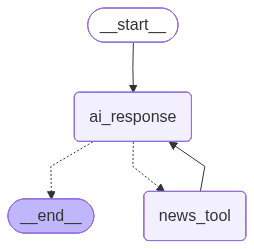

In [9]:
from IPython.display import display, Image
display(Image(news_agent.get_graph().draw_mermaid_png()))

In [ ]:
# User interaction function to manage chatbot conversations and retrieve responses
def process_user_request(user_prompt: str, session_id: str, show_details=False):
    """Manages AI chatbot interaction and retrieves responses."""
    
    with MemorySaver.from_conn_string("news_session.db") as session_store:
        session_agent = news_agent.compile(checkpointer=session_store)
        events = session_agent.stream(
            {"dialogue_history": [{"role": "user", "content": user_prompt}]},
            {"configurable": {"session_id": session_id}},
            stream_mode="values",  # Stream mode to get real-time responses
        )

    print("Processing request...")
    for event in events:
        if show_details:
            # Display intermediate responses if needed
            print(event["dialogue_history"][-1]["content"])

    # Final response from the chatbot
    return event["dialogue_history"][-1]["content"]


In [ ]:
# Streamlit UI for user interaction
st.title("NewsGenie: Your AI News Assistant")
user_session_id = st.text_input("Enter your session ID:", value="Guest01")
user_input = st.text_area("Enter your query or news category:")

if st.button("Get News"):
    if user_input.strip():
        response = process_user_request(user_input, user_session_id, show_details=True)
        st.subheader("NewsGenie Response:")
        st.write(response)
        
        # Add to history
        st.session_state.history.append({
            "query": user_input,
            "response": response,
            "timestamp": datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        })
    else:
        st.warning("Please enter a query or news category to get a response.")

st.write("## Session history")
if st.session_state.history:
    st.write("Your recent queries or news updates:")
    for item in st.session_state.history:
        st.write(f"**Query:** {item['query']}")
        st.write(f"**Response:** {item['response']}")
        st.write(f"**Time:** {item['timestamp']}")
        st.divider()
else:
    st.write("Your recent queries or news updates will appear here for reference.")

SyntaxError: incomplete input (3127019180.py, line 23)